In [1]:
import pandas as pd

In [3]:
df=pd.read_csv("placement.csv")

In [5]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [36]:
df.shape

(1000, 3)

In [7]:
#check distribution of both column cgpa and placement_exam_marks

In [8]:
import matplotlib.pyplot as plt

<Axes: ylabel='Density'>

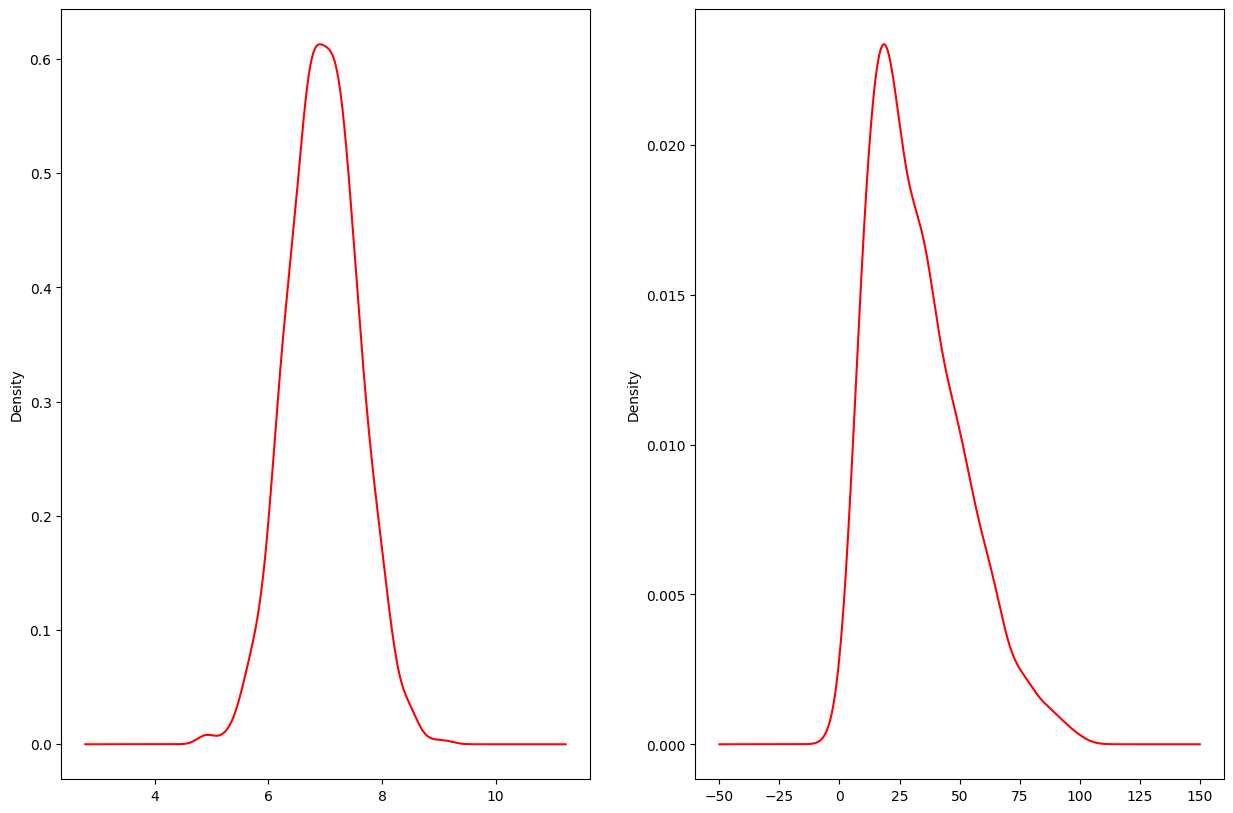

In [13]:
fig,ax=plt.subplots(1,2,figsize=(15,10))

df["cgpa"].plot(kind="kde",color="red",ax=ax[0])
df["placement_exam_marks"].plot(kind="kde",color="red",ax=ax[1])

In [15]:
#the z-score technique used only on distribution column.
#so cgpa column is fully distribution

In [17]:
df["cgpa"].describe()

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

In [18]:
#finding the boundary values


In [ ]:
df["cgpa"].mean()+3*df["cgpa"].std() #higher limit

np.float64(8.808933625397168)

In [24]:
df["cgpa"].mean()-3*df["cgpa"].std() #lower limit

np.float64(5.113546374602832)

In [26]:
# above 8.80-->outlier ,below 5.11-->outlier

In [28]:
# finding outlier

In [30]:
df[(df["cgpa"]>8.80) | (df["cgpa"]<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [31]:
#after this you can trimming or capping 

In [33]:
#Trimming 

new_df=df[(df["cgpa"]<8.80) & (df["cgpa"]>5.11)]

In [ ]:
new_df.shape

#the outlier are removed for the dataset

(995, 3)

In [39]:
#approach 2
#calculating the z score

In [42]:
df["cgpa_zscore"]=(df["cgpa"]-df["cgpa"].mean())/df["cgpa"].std()

In [44]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [47]:
df[df["cgpa_zscore"]>3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [50]:
df[df["cgpa_zscore"]<-3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [53]:
df[(df["cgpa_zscore"]>3)|(df["cgpa_zscore"]<-3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [56]:
#Trimming

In [60]:
new_df2=df[(df["cgpa_zscore"]<3) & (df["cgpa_zscore"]>-3)]

In [62]:
new_df2.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [64]:
new_df2.shape

(995, 4)

In [ ]:
#CAPPING 
#instead of removing outlier we can replace with limit

In [69]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [71]:
upper_limit=df["cgpa"].mean()+3*df["cgpa"].std()
lower_limit=df["cgpa"].mean()-3*df["cgpa"].std()

In [73]:
upper_limit

np.float64(8.808933625397168)

In [75]:
lower_limit

np.float64(5.113546374602832)

In [77]:
#capping 

In [79]:
df["cgpa"]=df["cgpa"].clip(lower=lower_limit,upper=upper_limit)

In [82]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [83]:
df.shape

(1000, 4)